# Gene2Wire Projection_TAGs: group × target blocks — OnDemand 0911

Projection-TAGs uses recorded animal IDs and preserves the native assay mask. Only targets measured in at least two animals are eligible. Standard detections remain natural; the union reference is an imperfect evaluation reference.

All existing input gene features are retained. A hidden group × target block contains
both positive and negative assay entries; none becomes a training negative.
The selected targets retain measured training support in other groups, and unselected
eligible targets remain shared. The same mask applies to every cell in a group.

Cells are split **within each group** into training, validation and outer test sets.
Only hidden entries on held-out test cells are scored. Their original references stay
outside preprocessing, calibration, fitting and selection. The full-panel control uses
the same test cells, features, paired cell IDs and tuning rules, but restores native
training/validation availability; it is fitted once and scored on each masked test subset.

This is a separate experiment from the primary 0908/0909 runs. It tests missing target
blocks for new cells within represented groups; it does not test new targets or unseen
animals. Artificial repetitions are not biological replication. No advantage is assumed.

Run top to bottom in an OnDemand Python 3.10+ kernel. Raw data and checkpoints persist;
exports remain under `/home/yueyue/gene2wire/paper_figure_exports`. Figures display here
and save as PDF only. Every code cell has a table-of-contents section.
To redraw completed results, set `RESULTS_ONLY=True` and supply exact saved run directories.
Compact diagnostics are the default: key aggregate metrics, selected configurations,
convergence and control comparisons stay visible, while raw tables remain exported.
Set `SHOW_FULL_DIAGNOSTICS=True` only when complete output is needed.
Progress reports once per minute; the worker cell reports CPU allowance and allocation
metadata separately from this experiment's active workers.


## Run configuration and masking strength


In [11]:
from pathlib import Path
import os

N_OUTER_FOLDS = 3
USE_LOCATION = False
USE_TARGET_FEATURES = False
N_JOBS = 64
PARALLEL_UNIT = 'scenario'
N_REPETITIONS = 5
STRATEGY = 'full_joint'
CANDIDATE_BUDGET = 32
SEED = 20260909
PAIRED_FRACTION = 0.20

# Fraction of eligible TARGETS receiving a partial group panel, not positive loss.
BLOCK_FRACTIONS = (0.20, 0.40, 0.60, 0.80)
GROUP_MODE = 'animal'
N_ARTIFICIAL_GROUPS = 2
VALIDATION_FRACTION = 0.20  # Fraction of each group's development cells.
INCLUDE_FULL_PANEL_CONTROL = True

# Isolate structural missingness by default. Optional: (0., .2, .4, .6, .8).
# Nonzero rates use SCAR with matched draws across masked/full training panels.
# Projection-TAGs always retains its natural observed assay and ignores this grid.
POSITIVE_LOSS_RATES = (0.0,)
RUN_INFORMATION_CONTROLS = True
RUN_RANDOM_FOREST = True
RUN_QIAO = True
SHOW_PROGRESS = True
PROGRESS_LEVEL = 'summary'
PROGRESS_INTERVAL_SECONDS = 60.0
SHOW_FULL_DIAGNOSTICS = False  # True opts into every raw table; output can be large.

BASE_DIR = Path('/home/yueyue/gene2wire').expanduser()
RAW_DATA_DIR = BASE_DIR / 'raw_data'
CHECKPOINT_DIR = BASE_DIR / 'checkpoints' / 'block_masking_v1'
EXPORT_DIR = BASE_DIR / 'paper_figure_exports'
FIGURE_DIR = BASE_DIR / 'figures' / '0911'
CODE_CACHE_DIR = BASE_DIR / 'code'
RESULTS_ONLY = False
EXISTING_EXPORT_DIRS = {'Projection-TAGs': None}  # Exact completed run directories.
CORE_COMMIT = '040a3035d9ad5e86505d31857f11ae2cab250615'
EXPECTED_SOURCE_HASH = 'ee6baafbe91f4d08daf99d25b9347440824527241a4042af1a3bd69b03b934e6'
REPO_URL = 'https://github.com/Yue-stat/Gene2Wire.git'
for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
                 'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[variable] = '1'

REQUIRED_MODULES = ['numpy', 'scipy', 'pandas', 'sklearn', 'joblib', 'threadpoolctl', 'matplotlib', 'yaml', 'IPython', 'rdata', 'openpyxl']
EXPECTED_EXPORT_LABELS = ('Projection-TAGs',)


## Load and verify the frozen shared core


In [12]:
import hashlib
import importlib.util
import re
import shutil
import subprocess
import sys
import tempfile

if sys.version_info < (3, 10):
    raise RuntimeError('Select an OnDemand Python 3.10 or newer kernel.')
if not re.fullmatch(r'[0-9a-f]{40}', CORE_COMMIT):
    raise RuntimeError('This notebook needs its released 40-character CORE_COMMIT pin.')
if not re.fullmatch(r'[0-9a-f]{64}', EXPECTED_SOURCE_HASH):
    raise RuntimeError('This notebook needs its released source checksum.')

def notebook_source_hash(package_root):
    # Same byte-level convention as experiments.protocol.source_hash().
    digest = hashlib.sha256()
    for source_path in sorted(package_root.rglob('*.py')):
        digest.update(source_path.relative_to(package_root).as_posix().encode())
        digest.update(source_path.read_bytes())
    return digest.hexdigest()

def verify_checkout(checkout, require_git_pin=True):
    package_root = checkout / 'src' / 'gene2wire'
    if not package_root.is_dir():
        raise RuntimeError(f'Missing Gene2Wire sources in {checkout}')
    if require_git_pin:
        actual_commit = subprocess.check_output(
            ['git', '-C', str(checkout), 'rev-parse', 'HEAD'], text=True).strip()
        if actual_commit != CORE_COMMIT:
            raise RuntimeError(f'Cached code has commit {actual_commit}, expected {CORE_COMMIT}.')
    if notebook_source_hash(package_root) != EXPECTED_SOURCE_HASH:
        raise RuntimeError(f'Source checksum mismatch in {checkout}; use the released code.')
    return checkout

# Running from the exact local repository is supported without any network call.
CORE_CHECKOUT = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    package_root = candidate / 'src' / 'gene2wire'
    if package_root.is_dir() and notebook_source_hash(package_root) == EXPECTED_SOURCE_HASH:
        CORE_CHECKOUT = verify_checkout(candidate, require_git_pin=False)
        break

if CORE_CHECKOUT is None:
    CODE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cached_checkout = CODE_CACHE_DIR / CORE_COMMIT
    if not cached_checkout.exists():
        stage = Path(tempfile.mkdtemp(prefix='.gene2wire-download-', dir=CODE_CACHE_DIR))
        try:
            for arguments in (
                ['git', 'init', '--quiet', str(stage)],
                ['git', '-C', str(stage), 'remote', 'add', 'origin', REPO_URL],
                ['git', '-C', str(stage), 'fetch', '--quiet', '--depth', '1', 'origin', CORE_COMMIT],
                ['git', '-C', str(stage), 'checkout', '--quiet', '--detach', 'FETCH_HEAD'],
            ):
                subprocess.run(arguments, check=True)
            verify_checkout(stage)
            try:
                stage.rename(cached_checkout)
            except OSError:
                # Another notebook may have completed this same immutable cache.
                if not cached_checkout.exists():
                    raise
                verify_checkout(cached_checkout)
        finally:
            if stage.exists():
                shutil.rmtree(stage)
    CORE_CHECKOUT = verify_checkout(cached_checkout)

existing = sys.modules.get('gene2wire')
if existing is not None:
    same_path = Path(existing.__file__).resolve().parent == (CORE_CHECKOUT / 'src' / 'gene2wire').resolve()
    same_source = getattr(existing, '_notebook_source_hash_0908', None) == EXPECTED_SOURCE_HASH
    if not (same_path and same_source):
        raise RuntimeError('A different or unverified gene2wire is already imported. Restart the kernel, then Run All.')

missing = [name for name in REQUIRED_MODULES if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('Use an OnDemand Python kernel containing these dependencies: '
                       + ', '.join(missing) + '. See the repository environment instructions.')
sys.path.insert(0, str(CORE_CHECKOUT / 'src'))
import gene2wire
from gene2wire.experiments.protocol import Settings, source_hash
if source_hash() != EXPECTED_SOURCE_HASH:
    raise RuntimeError('Imported code does not match the released source checksum.')
gene2wire._notebook_source_hash_0908 = EXPECTED_SOURCE_HASH
for directory in (RAW_DATA_DIR, CHECKPOINT_DIR, EXPORT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print({'core_commit': CORE_COMMIT, 'source_hash': source_hash(),
       'imported_from': gene2wire.__file__, 'raw_cache': str(RAW_DATA_DIR),
       'checkpoints': str(CHECKPOINT_DIR), 'exports': str(EXPORT_DIR)})


{'core_commit': '040a3035d9ad5e86505d31857f11ae2cab250615', 'source_hash': 'ee6baafbe91f4d08daf99d25b9347440824527241a4042af1a3bd69b03b934e6', 'imported_from': '/home/yueyue/gene2wire/code/040a3035d9ad5e86505d31857f11ae2cab250615/src/gene2wire/__init__.py', 'raw_cache': '/home/yueyue/gene2wire/raw_data', 'checkpoints': '/home/yueyue/gene2wire/checkpoints/block_masking_v1', 'exports': '/home/yueyue/gene2wire/paper_figure_exports'}


## Shared model and block settings

All datasets use the same model implementations, candidate budgets and exact Joint
endpoints. Only group source, native availability and feature adapters differ.
Paired references authorize visible entries of the same selected cells, never blocked
entries. Nonzero optional positive loss uses simple SCAR, separately from structural masks.
Qiao uses target identity when target features are disabled; enabling the switch requires
the adapter's declared outcome-independent target descriptors.


In [13]:
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython.display import display
from gene2wire.experiments.block_design import BlockMaskConfig
from gene2wire.experiments.block_experiment import (
    run_block_experiment, run_block_simulation_experiments, preview_block_experiment,
)
from gene2wire.experiments.block_plotting import plot_block_results
from gene2wire.experiments.reporting import (
    configure_full_display, configure_compact_display, load_existing_exports, display_diagnostics,
)
from gene2wire.tuning import full_joint_candidates

if SHOW_FULL_DIAGNOSTICS:
    configure_full_display()
else:
    configure_compact_display()
settings = Settings(
    n_outer_folds=N_OUTER_FOLDS, use_location=USE_LOCATION,
    use_target_features=USE_TARGET_FEATURES, n_jobs=N_JOBS,
    parallel_unit=PARALLEL_UNIT, n_repetitions=N_REPETITIONS,
    strategy=STRATEGY, candidate_budget=CANDIDATE_BUDGET, seed=SEED,
    paired_fraction=PAIRED_FRACTION, calibration_fractions=(PAIRED_FRACTION,),
    loss_rates=POSITIVE_LOSS_RATES,
    run_information_controls=RUN_INFORMATION_CONTROLS,
    run_random_forest=RUN_RANDOM_FOREST, run_qiao=RUN_QIAO,
    run_mechanism_controls=False, run_calibration_controls=False,
)
block_config = BlockMaskConfig(
    fractions=BLOCK_FRACTIONS, group_mode=GROUP_MODE,
    n_artificial_groups=N_ARTIFICIAL_GROUPS,
    validation_fraction=VALIDATION_FRACTION,
    include_full_panel_control=INCLUDE_FULL_PANEL_CONTROL,
)
if SHOW_FULL_DIAGNOSTICS:
    display(pd.DataFrame([asdict(settings)]).T.rename(columns={0: 'shared settings'}))
    display(pd.DataFrame([asdict(block_config)]).T.rename(columns={0: 'block design'}))
else:
    print({'folds': N_OUTER_FOLDS, 'repetitions': N_REPETITIONS, 'n_jobs': N_JOBS,
           'use_location': USE_LOCATION, 'use_target_features': USE_TARGET_FEATURES,
           'paired_fraction': PAIRED_FRACTION, 'block_fractions': BLOCK_FRACTIONS,
           'positive_loss_rates': POSITIVE_LOSS_RATES, 'group_mode': GROUP_MODE,
           'full_panel_control': INCLUDE_FULL_PANEL_CONTROL})
if RESULTS_ONLY:
    all_artifacts = load_existing_exports(
        EXISTING_EXPORT_DIRS, expected_labels=EXPECTED_EXPORT_LABELS)
    print('RESULTS_ONLY: using saved manifests; raw loading and fitting are skipped.')


{'folds': 3, 'repetitions': 5, 'n_jobs': 64, 'use_location': False, 'use_target_features': False, 'paired_fraction': 0.2, 'block_fractions': (0.2, 0.4, 0.6, 0.8), 'positive_loss_rates': (0.0,), 'group_mode': 'animal', 'full_panel_control': True}


## CPU allocation and live experiment workers

Reports the kernel CPU allowance and detectable machine, affinity, scheduler and cgroup
allocation limits. This experiment's active workers are shown separately. Other users'
idle CPUs on the node cannot be inferred from this notebook.


In [14]:
from gene2wire.experiments.workers import NotebookWorkerStatus

worker_status = None
if RESULTS_ONLY:
    print('RESULTS_ONLY: no training workers are launched.')
else:
    worker_status = NotebookWorkerStatus(requested_workers=N_JOBS)


## Preview design and tuning candidates


In [15]:
def preflight_blocks(dataset):
    dataset.validate()
    preview = preview_block_experiment(dataset, settings, block_config, repetition=0)
    groups, folds, design = preview['groups'], preview['folds'], preview['design']
    features = dataset.feature_builder(
        folds[0].train_rows, settings.use_location, settings.use_target_features)
    display(pd.DataFrame([{
        'dataset': dataset.name, 'cells': len(dataset.cell_ids),
        'targets': len(dataset.target_ids), 'groups': len(np.unique(groups)),
        'feature_columns': features.X.shape[1],
        'feature_blocks': dict(features.feature_blocks),
        'target_feature_columns': 0 if features.Y_target is None else features.Y_target.shape[1],
        'native_measured_pairs': int(dataset.measured.sum()),
        'natural_paired_assay': dataset.natural_observed is not None,
    }]))
    display(pd.Series(groups).value_counts().rename_axis('group').to_frame('cells'))
    print('Repetition 0 design; actual fractions account for rounded target counts and native coverage:')
    summary_columns = ['block_fraction', 'n_eligible_targets', 'n_selected_targets',
                       'realized_eligible_target_fraction', 'n_hidden_pairs',
                       'realized_pair_fraction', 'duplicate_of_fraction']
    display(design.summary if SHOW_FULL_DIAGNOSTICS else design.summary[summary_columns])
    display(pd.DataFrame([
        {'fold': f.outer_fold, 'inner_train': len(f.train_rows),
         'validation': len(f.validation_rows), 'test': len(f.test_rows),
         'split': f.metadata['split_type']} for f in folds]))
    if SHOW_FULL_DIAGNOSTICS:
        display(design.assignment)
    tuning = settings.tuning_config(features.X.shape[1], len(dataset.target_ids))
    candidates = []
    for model in settings.models():
        candidates.extend({'model': model.name, 'candidate': index, **asdict(candidate)}
                          for index, candidate in enumerate(full_joint_candidates(model, tuning), 1))
    candidate_table = pd.DataFrame(candidates)
    if SHOW_FULL_DIAGNOSTICS:
        display(candidate_table)
        display(pd.DataFrame([asdict(settings.fit_config())]))
    else:
        display(candidate_table.groupby('model').size().to_frame('candidates'))
    print('No input genes are masked. Each group appears in training, validation and test.')
    print('Blocked entries are excluded from calibration, model fitting and validation scoring.')


## Optional Projection-TAGs feature inputs


In [16]:
LOCATION_FEATURES_CSV = None
TARGET_FEATURES_CSV = None


## Load cached Projection-TAGs inputs and native assay coverage


In [17]:
if not RESULTS_ONLY:
    from gene2wire.experiments.datasets.projection_tags import load_projection_tags
    dataset = load_projection_tags(
        RAW_DATA_DIR / 'Projection_TAGs',
        location_features_csv=LOCATION_FEATURES_CSV,
        target_features_csv=TARGET_FEATURES_CSV)
    preflight_blocks(dataset)


,dataset,cells,targets,groups,feature_columns,feature_blocks,target_feature_columns,native_measured_pairs,natural_paired_assay
0,Projection-TAGs,37827,7,6,32,"{'gene': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...",0,245825,True


,cells
group,
6,9947
5,8916
1,6694
4,4559
2,4166
3,3545


Repetition 0 design; actual fractions account for rounded target counts and native coverage:


,block_fraction,n_eligible_targets,n_selected_targets,realized_eligible_target_fraction,n_hidden_pairs,realized_pair_fraction,duplicate_of_fraction
0,0.2,7,1,0.142857,18672,0.075956,NaN
1,0.4,7,3,0.428571,41993,0.170825,NaN
2,0.6,7,4,0.571429,61148,0.248746,NaN
3,0.8,7,6,0.857143,102621,0.417456,NaN


,fold,inner_train,validation,test,split
0,0,20170,5046,12611,within_group_new_cell
1,1,20171,5046,12610,within_group_new_cell
2,2,20175,5046,12606,within_group_new_cell


,candidates
model,
Joint,32
Logistic,6
MIRT,24
PU,6
PU-Joint,32
PU-MIRT,24


No input genes are masked. Each group appears in training, validation and test.
Blocked entries are excluded from calibration, model fitting and validation scoring.


## Run all block settings and the full-panel control

This is the expensive step. A model unit includes its tuning and final refit.
Compatible completed units and partial fit caches resume automatically. The full-panel
control is not refitted for every evaluation fraction. At zero additional thinning,
ordinary and PU objectives can coincide; overlapping curves are expected.


In [18]:
if not RESULTS_ONLY:
    artifacts = run_block_experiment(
        dataset=dataset, settings=settings, block_config=block_config,
        checkpoint_dir=CHECKPOINT_DIR, export_dir=EXPORT_DIR,
        progress=SHOW_PROGRESS, progress_level=PROGRESS_LEVEL,
        progress_interval=PROGRESS_INTERVAL_SECONDS, worker_status=worker_status)
    all_artifacts = {'Projection-TAGs': artifacts}


[cache] verified result summaries 1125/1125; remaining 0 require cache checks or processing. Model/candidate/refit reuse is counted during execution; unchecked does not mean uncached.
[finished 0min] finished units 1125/1125, current time 2026-09-11 12:18:44 PDT; restored results 1125, reused fits 0, new/mixed 0
All results exported to: /home/yueyue/gene2wire/paper_figure_exports/Projection-TAGs_target_block/3fec298580c17638d7ef


## Curves on structurally hidden test entries

Panels show AUPRC, log loss and Brier score against the fraction of eligible targets
assigned a partial panel. The full-panel row uses the same hidden test subsets, so its
curve can change as evaluation targets change even though its fitted model is reused.
All scores use raw predictions; a missing assay is not an observed negative and receives
no non-detection posterior. Thus Hidden Recall@H is not used in this experiment.
Additional plots show all benchmarks, methods without direct reference supervision,
and the three same-budget reference-plus-observation methods. A separate
`extra_sharing_gain_auprc` plot shows masked-panel minus full-panel model advantage,
with one standard error across repetitions after averaging folds. Real-data error bars
describe repeated mask/split variation, not biological sampling uncertainty.


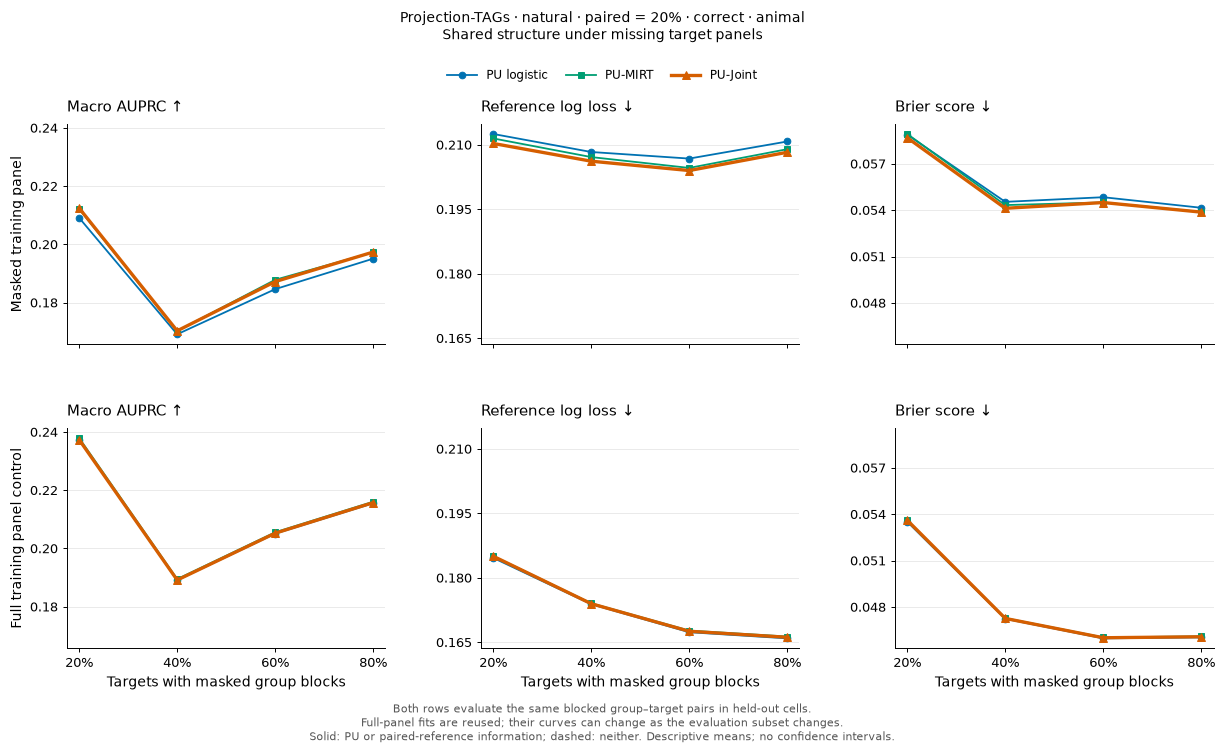

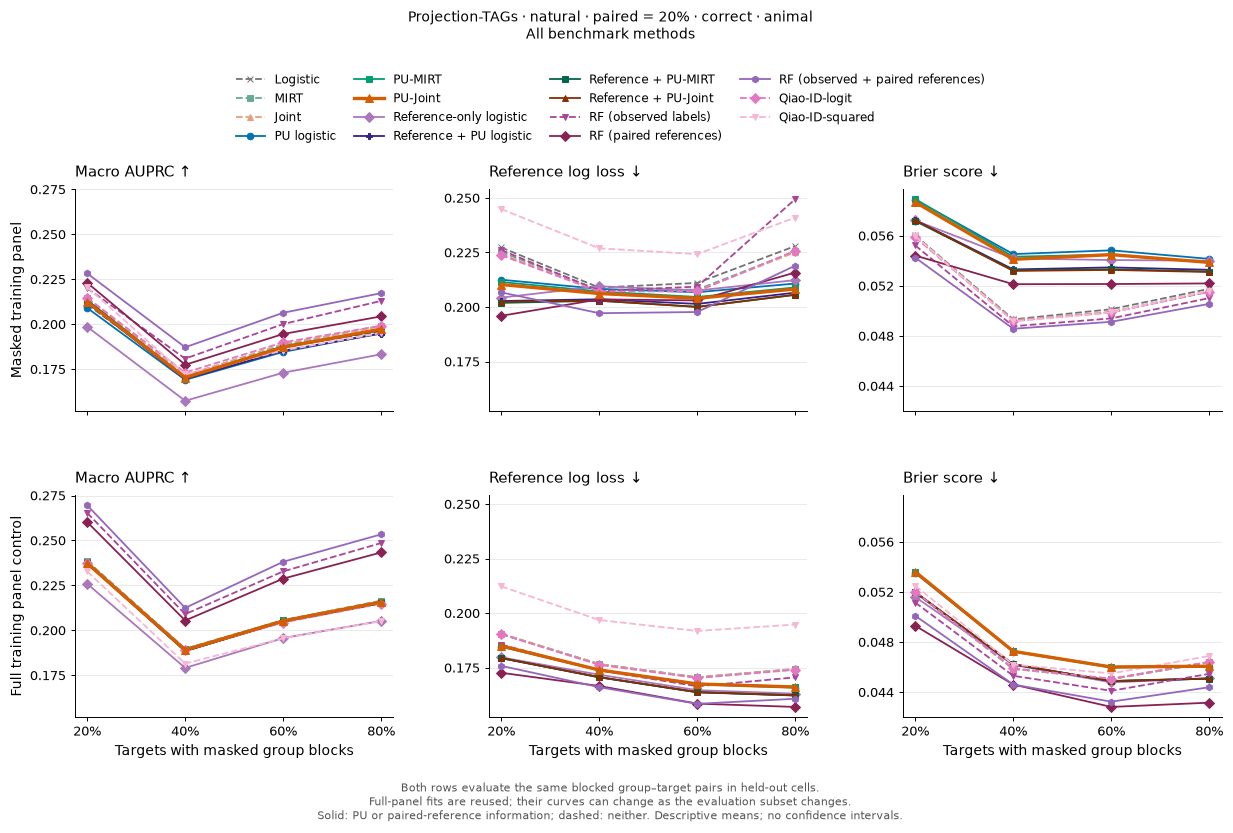

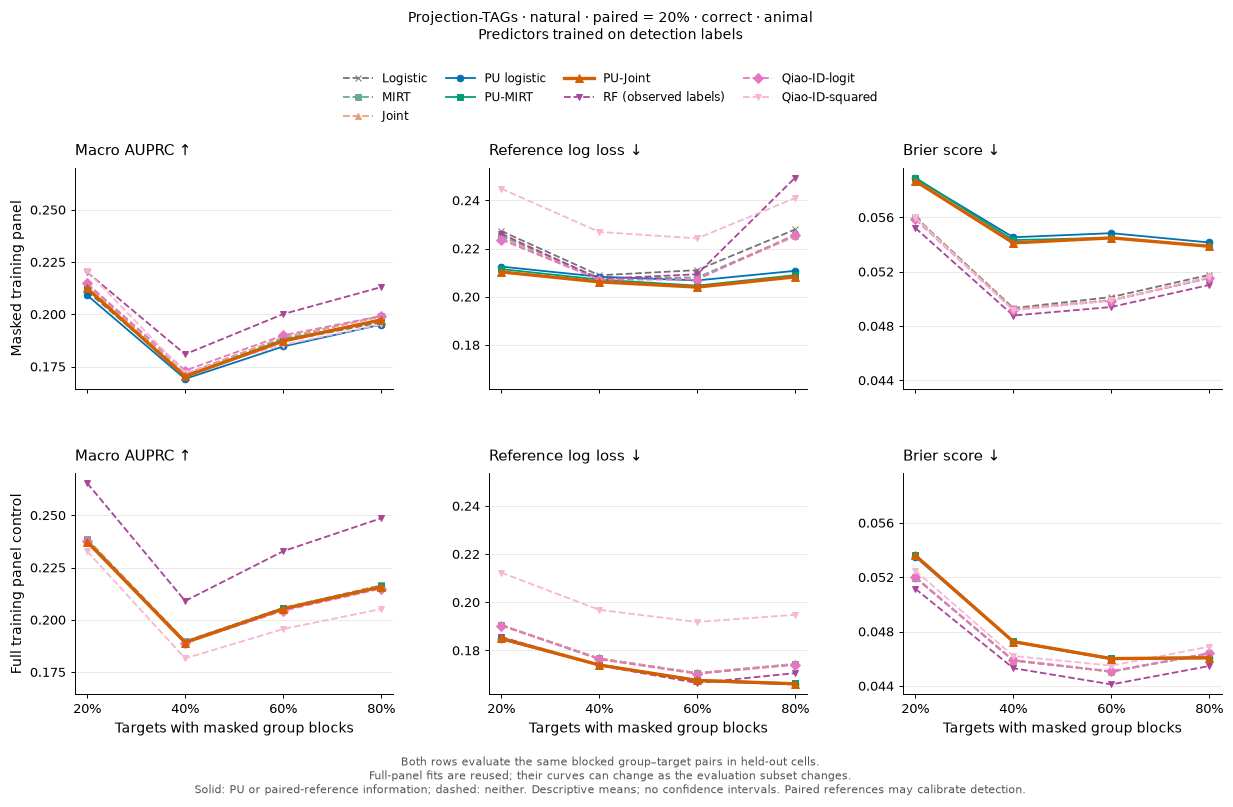

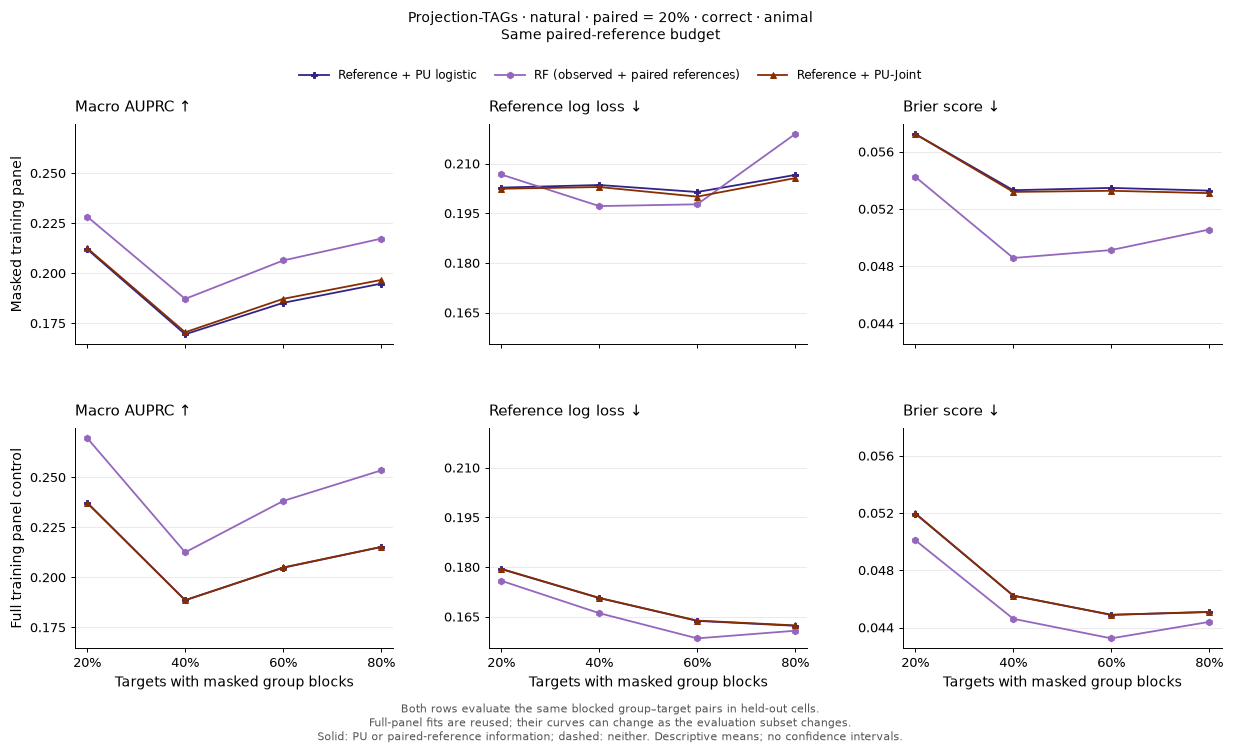

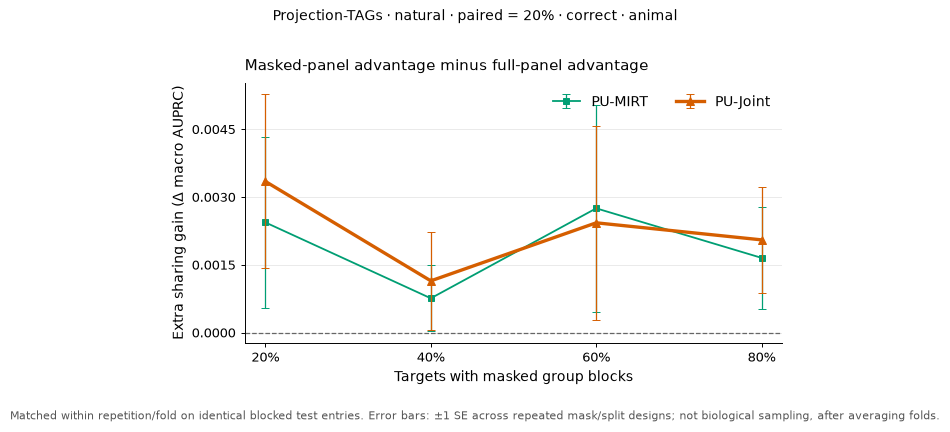

{'Projection-TAGs': {'dataset_Projection-TAGs__experiment_target_block__group_mode_animal__analysis_primary__mechanism_natural__calibration_fraction_0_2__calibration_spec_correct__primary': PosixPath('/home/yueyue/gene2wire/figures/0911/block_masking/primary/dataset_Projection-TAGs__experiment_target_block__group_mode_animal__analysis_primary__mechanism_natural__calibration_fraction_0_2__calibration_spec_correct__primary.pdf'),
  'dataset_Projection-TAGs__experiment_target_block__group_mode_animal__analysis_primary__mechanism_natural__calibration_fraction_0_2__calibration_spec_correct__all_benchmarks': PosixPath('/home/yueyue/gene2wire/figures/0911/block_masking/all_benchmarks/dataset_Projection-TAGs__experiment_target_block__group_mode_animal__analysis_primary__mechanism_natural__calibration_fraction_0_2__calibration_spec_correct__all_benchmarks.pdf'),
  'dataset_Projection-TAGs__experiment_target_block__group_mode_animal__analysis_primary__mechanism_natural__calibration_fraction_0_2_

In [19]:
figure_paths = {}
for label, artifacts in all_artifacts.items():
    figure_paths[label] = plot_block_results(
        artifacts, output_dir=FIGURE_DIR, show=True, include_benchmarks=True)
display(figure_paths)


## Essential results and selected hyperparameters

The default report bounds output and retains aggregate metrics, important-model
selections by repetition, convergence, calibration and matched block/control diagnostics.
It states when rows are omitted. Every raw table remains exported;
`SHOW_FULL_DIAGNOSTICS=True` explicitly opts into large output.


In [20]:
for label, artifacts in all_artifacts.items():
    display_diagnostics(artifacts, label=label, full=SHOW_FULL_DIAGNOSTICS)
print('PDF figures:', FIGURE_DIR)
print('Persistent checkpoints:', CHECKPOINT_DIR)
print('Reusable raw data:', RAW_DATA_DIR)



Projection-TAGs — concise diagnostics
All result tables, predictions and settings: /home/yueyue/gene2wire/paper_figure_exports/Projection-TAGs_target_block/3fec298580c17638d7ef
Saved run settings (authoritative for these results): {'n_outer_folds': 3, 'n_repetitions': 5, 'use_location': False, 'use_target_features': False, 'paired_fraction': 0.2, 'strategy': 'full_joint', 'candidate_budget': 32}
Execution settings recorded in this export: {'parallel_unit': 'scenario', 'requested_n_jobs': 64, 'effective_n_jobs': 0, 'scheduled_tasks': 0, 'planned_model_evaluations': 1125, 'cached_model_evaluations': 1125, 'reused_fit_model_evaluations': 0, 'new_or_mixed_model_evaluations': 0, 'unknown_fit_model_evaluations': 0}
Metric means give folds equal weight within each repetition, then repetitions equal weight. Endpoints use each model's largest recorded primary loss (or natural paired labels); block experiments use the largest block fraction and masked training. PU curves retain all primary loss

,model,probability_semantics,macro_auprc,macro_log_loss,macro_brier,macro_predicted_prevalence,macro_reference_prevalence
0,Joint,observed,0.198892,0.225113,0.051578,0.026634,0.055598
1,Logistic,observed,0.196219,0.227955,0.051765,0.026665,0.055598
2,MIRT,observed,0.199205,0.225482,0.051544,0.026655,0.055598
3,PU,reference,0.195091,0.210769,0.054153,0.053551,0.055598
4,PU-Joint,reference,0.197359,0.208264,0.053871,0.053873,0.055598
5,PU-MIRT,reference,0.197270,0.208980,0.053883,0.053855,0.055598
6,Qiao-ID-logit,observed,0.199183,0.225830,0.051537,0.026701,0.055598
7,Qiao-ID-squared,observed,0.195138,0.241003,0.051598,0.030598,0.055598
8,RF-mixed,mixed,0.217304,0.218963,0.050564,0.033386,0.055598
9,RF-observed,observed,0.212996,0.249467,0.051026,0.027375,0.055598



pu_curves: showing 12/12 rows
Fixed coordinates: dataset=Projection-TAGs; sharing_strength=nan; analysis=primary; mechanism=natural; loss_rate=nan; calibration_fraction=0.2; calibration_spec=correct; experiment=target_block; group_mode=animal; training_panel=masked; evaluation_scope=blocked; probability_semantics=reference


,block_fraction,model,macro_auprc,macro_log_loss,macro_brier,macro_predicted_prevalence
0,0.2,PU,0.209108,0.212522,0.058878,0.057798
1,0.4,PU,0.169119,0.208326,0.054536,0.068401
2,0.6,PU,0.184619,0.206795,0.054836,0.062705
3,0.8,PU,0.195091,0.210769,0.054153,0.053551
4,0.2,PU-Joint,0.212444,0.210315,0.058681,0.058378
5,0.4,PU-Joint,0.170302,0.206188,0.054119,0.068094
6,0.6,PU-Joint,0.187209,0.204016,0.054491,0.062931
7,0.8,PU-Joint,0.197359,0.208264,0.053871,0.053873
8,0.2,PU-MIRT,0.212116,0.211485,0.058926,0.058376
9,0.4,PU-MIRT,0.170239,0.207146,0.054327,0.068134



selected_hyperparameters_by_repetition: showing 20/20 rows
Fixed coordinates: dataset=Projection-TAGs; sharing_strength=nan; analysis=primary; mechanism=natural; loss_rate=nan; calibration_fraction=0.2; calibration_spec=correct; experiment=target_block; group_mode=animal; training_panel=masked; training_block_fraction=0.8


...


detection_calibration: showing 1/1 rows
Fixed coordinates: dataset=Projection-TAGs; sharing_strength=nan; analysis=primary; mechanism=natural; loss_rate=nan; calibration_fraction=0.2; calibration_spec=correct; experiment=target_block; group_mode=animal; training_panel=masked; training_block_fraction=0.8


,detection_log_loss,detection_brier,detection_mean,detection_observed_rate
0,0.679105,0.242973,0.510504,0.511621



matched_full_panel_control: showing 12/12 rows
Fixed coordinates: dataset=Projection-TAGs; sharing_strength=nan; analysis=primary; mechanism=natural; loss_rate=nan; calibration_fraction=0.2; calibration_spec=correct; experiment=target_block; group_mode=animal; evaluation_scope=blocked
Matched rep/fold/test entries: positive masking_loss means masking hurt. Positive extra_sharing_gain means masking increased the model's advantage over PU; zero means no additional sharing gain attributable to panel masking. Values average paired differences, not unmatched aggregates.


,block_fraction,model,masking_loss_auprc,masking_loss_log_loss,masking_loss_brier,extra_sharing_gain_auprc,extra_sharing_gain_log_loss,extra_sharing_gain_brier
0,0.2,PU,0.028244,0.027882,0.005368,0.000000,0.000000,0.000000
1,0.2,PU-Joint,0.024898,0.025291,0.005073,0.003346,0.002590,0.000295
2,0.2,PU-MIRT,0.025805,0.026424,0.005315,0.002439,0.001458,0.000052
3,0.4,PU,0.020000,0.034461,0.007301,0.000000,0.000000,0.000000
4,0.4,PU-Joint,0.018853,0.032209,0.006857,0.001146,0.002252,0.000444
5,0.4,PU-MIRT,0.019239,0.033070,0.007048,0.000760,0.001390,0.000254
6,0.6,PU,0.020471,0.039450,0.008864,0.000000,0.000000,0.000000
7,0.6,PU-Joint,0.018041,0.036447,0.008480,0.002430,0.003003,0.000384
8,0.6,PU-MIRT,0.017720,0.036900,0.008461,0.002751,0.002550,0.000403
9,0.8,PU,0.020438,0.044857,0.008116,0.000000,0.000000,0.000000


Recorded failed units: 0.
All scenarios, final-fit records: 1125; not converged: 0; status not recorded: 225.
All scenarios, candidate records: 20700; not converged: 0; status not recorded: 2700.
Compact output is capped at 8 tables / 300 rows / 14 columns. Set SHOW_FULL_DIAGNOSTICS=True to display every saved table and the full manifest.
PDF figures: /home/yueyue/gene2wire/figures/0911
Persistent checkpoints: /home/yueyue/gene2wire/checkpoints/block_masking_v1
Reusable raw data: /home/yueyue/gene2wire/raw_data
